# Super Base de Commodities - Descarga de Datos

**Universidad de Buenos Aires - Facultad de Ciencias Económicas**  
**Taller de Programación - Big Data**  
**Año 2025**

---

## Objetivo

Descargar datos históricos de commodities desde dos fuentes:

1. **Kaggle - mattiuzc** - Datos históricos (2000-2021)
2. **Yahoo Finance - yfinance** - Datos recientes (2021-2025)

**Estrategia:** Empalmar ambas fuentes para crear series continuas de 25 años.

**Siguiente paso:** `02_process_data.ipynb` - Procesamiento, feature engineering y visualización.


## 📌 Fuente 1: Kaggle - Datos Históricos (2000-2021)

### Dataset: Commodity Futures Price History (mattiuzc)

**Precios diarios de futuros de commodities desde Yahoo Finance (datos históricos).**

- **URL:** https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history
- **Cobertura:** ~20 años de historia (2000 - Junio 2021)
- **Formato:** 23 archivos CSV individuales
- **Columnas:** Date, Open, High, Low, Close, Adj Close, Volume

**Commodities incluidos:**
- **Granos:** Corn, Soybean, Wheat, Oat, Soybean Oil, Soybean Meal
- **Energía:** Crude Oil, Brent Crude Oil, Natural Gas, Heating Oil, RBOB Gasoline
- **Metales preciosos:** Gold, Silver, Platinum, Palladium
- **Metales industriales:** Copper
- **Softs:** Coffee, Sugar, Cotton, Cocoa
- **Ganado:** Live Cattle, Feeder Cattle, Lean Hogs
- **Madera:** Lumber

---

### Descarga automática con Kaggle API

**Opción 1 (Recomendada): Descarga automática**

La celda siguiente descarga automáticamente el dataset usando la API de Kaggle.

**Requisitos previos:**
1. Tener cuenta en Kaggle: https://www.kaggle.com/account/login
2. Configurar API token:
   - Ir a Settings > API > "Create New Token"
   - Guardar `kaggle.json` en:
     - **Windows:** `C:\Users\<tu_usuario>\.kaggle\`
     - **Linux/Mac:** `~/.kaggle/`
3. Instalar kaggle: `pip install kaggle`

**Opción 2 (Manual):**
1. Descargar ZIP desde: https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history
2. Descomprimir en `data/raw/kaggle/mattiuzc_futures/`

### Descarga automática desde Kaggle

Si no tenés los archivos, esta celda los descarga automáticamente.

In [47]:
import os
import zipfile
from pathlib import Path

# Configurar rutas
BASE_DIR = Path.cwd()
KAGGLE_DIR = BASE_DIR / 'data' / 'raw' / 'kaggle' / 'mattiuzc_futures'
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

# Verificar si ya tenemos los datos
csv_files = list(KAGGLE_DIR.glob('*.csv'))
kaggle_files = [f for f in csv_files if not f.name.endswith('_yahoo.csv')]

if len(kaggle_files) >= 20:
    print(f"✓ Dataset ya descargado: {len(kaggle_files)} archivos encontrados")
    print("  Saltando descarga automática...")
else:
    print(f"📥 Descargando dataset desde Kaggle...")
    print(f"   Archivos actuales: {len(kaggle_files)}/23")
    
    try:
        # Importar API de Kaggle
        from kaggle.api.kaggle_api_extended import KaggleApi
        
        # Autenticar
        api = KaggleApi()
        api.authenticate()
        
        # Descargar dataset
        dataset_name = "mattiuzc/commodity-futures-price-history"
        download_path = BASE_DIR / 'data' / 'raw' / 'kaggle'
        
        print(f"\n   Descargando: {dataset_name}")
        api.dataset_download_files(dataset_name, path=download_path, unzip=True)
        
        # Mover archivos a la carpeta correcta
        temp_folder = download_path / 'commodity-futures-price-history'
        if temp_folder.exists():
            for file in temp_folder.glob('*.csv'):
                target = KAGGLE_DIR / file.name
                file.rename(target)
            temp_folder.rmdir()
        
        # Verificar descarga
        csv_files_new = list(KAGGLE_DIR.glob('*.csv'))
        kaggle_files_new = [f for f in csv_files_new if not f.name.endswith('_yahoo.csv')]
        
        print(f"\n✓ Descarga completada: {len(kaggle_files_new)} archivos")
        print(f"  Ubicación: {KAGGLE_DIR.relative_to(BASE_DIR)}/")
        
    except ImportError:
        print("\n❌ ERROR: Biblioteca 'kaggle' no instalada")
        print("   Solución: pip install kaggle")
        print("\n   Alternativa: Descargar manualmente desde:")
        print("   https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history")
        
    except Exception as e:
        print(f"\n❌ ERROR en descarga automática: {e}")
        print("\n   Posibles causas:")
        print("   1. No configuraste kaggle.json (ver instrucciones arriba)")
        print("   2. No tenés conexión a internet")
        print("   3. Kaggle cambió la API")
        print("\n   Alternativa: Descargar manualmente desde:")
        print("   https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history")


✓ Dataset ya descargado: 24 archivos encontrados
  Saltando descarga automática...


---

## 0. Configuración Inicial

Verificamos dependencias y cargamos librerías.

In [48]:
# Imports
import os
import sys
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
from IPython.display import display, HTML, Markdown

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Librerías cargadas correctamente")
print(f"Pandas versión: {pd.__version__}")
print(f"Numpy versión: {np.__version__}")


✓ Librerías cargadas correctamente
Pandas versión: 2.2.3
Numpy versión: 1.26.4


### Verificar estructura de carpetas

In [49]:
# Crear estructura si no existe
BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / 'data' / 'raw'
INTERIM_DIR = BASE_DIR / 'data' / 'interim'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Crear subcarpetas para datos de Kaggle
folders = [
    RAW_DIR / 'kaggle' / 'mattiuzc_futures',      # Dataset mattiuzc (CSV históricos + Yahoo)
    INTERIM_DIR,
    PROCESSED_DIR
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("✓ Estructura de carpetas verificada:")
for folder in folders:
    print(f"  {folder.relative_to(BASE_DIR)}/")

# Verificar si existen archivos de Kaggle
kaggle_mattiuzc = RAW_DIR / 'kaggle' / 'mattiuzc_futures'
csv_files_mattiuzc = list(kaggle_mattiuzc.glob('*.csv'))

print(f"\n📂 Archivos encontrados en mattiuzc_futures/: {len(csv_files_mattiuzc)} archivos")
if csv_files_mattiuzc:
    # Separar archivos históricos de Kaggle vs descargados de Yahoo
    kaggle_files = [f for f in csv_files_mattiuzc if not f.name.endswith('_yahoo.csv')]
    yahoo_files = [f for f in csv_files_mattiuzc if f.name.endswith('_yahoo.csv')]
    
    print(f"\n  📥 Kaggle históricos (2000-2021): {len(kaggle_files)} archivos")
    for f in sorted(kaggle_files)[:5]:
        print(f"    ✓ {f.name}")
    if len(kaggle_files) > 5:
        print(f"    ... y {len(kaggle_files) - 5} más")
    
    if yahoo_files:
        print(f"\n  📥 Yahoo Finance (2021-2025): {len(yahoo_files)} archivos")
        for f in sorted(yahoo_files)[:5]:
            print(f"    ✓ {f.name}")
        if len(yahoo_files) > 5:
            print(f"    ... y {len(yahoo_files) - 5} más")
else:
    print("\n  ⚠️  NINGÚN ARCHIVO - Descargar datasets de Kaggle primero")
    print("     Ver instrucciones en celda anterior")


✓ Estructura de carpetas verificada:
  data\raw\kaggle\mattiuzc_futures/
  data\interim/
  data\processed/

📂 Archivos encontrados en mattiuzc_futures/: 48 archivos

  📥 Kaggle históricos (2000-2021): 24 archivos
    ✓ Brent Crude Oil.csv
    ✓ Cocoa.csv
    ✓ Coffee.csv
    ✓ Copper.csv
    ✓ Corn.csv
    ... y 19 más

  📥 Yahoo Finance (2021-2025): 24 archivos
    ✓ brent_crude_oil_yahoo.csv
    ✓ cocoa_yahoo.csv
    ✓ coffee_yahoo.csv
    ✓ copper_yahoo.csv
    ✓ corn_yahoo.csv
    ... y 19 más


---

## 1. Carga de Futuros CBOT (Kaggle - mattiuzc)

Cargamos precios diarios de contratos continuos desde Yahoo Finance:
- **ZC=F.csv** - Corn (maíz) futures
- **ZS=F.csv** - Soybeans (soja) futures  
- **ZW=F.csv** - Wheat (trigo) futures

**Período esperado:** ~20 años de historia (hasta Jun 2021)

In [50]:
def load_kaggle_futures():
    """
    Carga archivos CSV de futuros desde Kaggle (dataset mattiuzc)
    
    Returns:
        dict: {commodity_name: DataFrame}
    """
    
    kaggle_dir = RAW_DIR / 'kaggle' / 'mattiuzc_futures'
    
    # Mapeo de nombres de archivo a commodities
    file_mapping = {
        'corn.csv': 'Corn',
        'soybean.csv': 'Soybeans',
        'wheat.csv': 'Wheat',
        'crude oil.csv': 'Crude_Oil',
        'gold.csv': 'Gold',
        'silver.csv': 'Silver',
        'natural gas.csv': 'Natural_Gas',
    }
    
    futures_data = {}
    
    print("=" * 60)
    print("CARGA DE FUTUROS DESDE KAGGLE (mattiuzc)")
    print("=" * 60 + "\n")
    
    csv_files = list(kaggle_dir.glob('*.csv'))
    
    if not csv_files:
        print("✗ NO SE ENCONTRARON ARCHIVOS")
        print(f"\nUbicación esperada: {kaggle_dir.relative_to(BASE_DIR)}/")
        print("\nDescargar dataset desde:")
        print("https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history")
        print("\nArchivos esperados: Corn.csv, Soybean.csv, Wheat.csv, etc.")
        return futures_data
    
    for csv_file in csv_files:
        filename_lower = csv_file.name.lower()
        
        # Buscar nombre de commodity en el mapeo
        commodity_name = file_mapping.get(filename_lower)
        
        # Si no está en el mapeo, usar el nombre del archivo (sin .csv)
        if not commodity_name:
            commodity_name = csv_file.stem.replace(' ', '_')
        
        try:
            print(f"Cargando {csv_file.name}...", end=' ')
            
            df = pd.read_csv(csv_file)
            
            # Estandarizar columna de fecha
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'])
            elif 'date' in df.columns:
                df['Date'] = pd.to_datetime(df['date'])
                df = df.drop('date', axis=1)
            
            df = df.sort_values('Date').reset_index(drop=True)
            
            print(f"✓ {len(df):,} obs. ({df['Date'].min().date()} → {df['Date'].max().date()})")
            
            futures_data[commodity_name] = df
            
        except Exception as e:
            print(f"✗ Error: {e}")
    
    print("\n" + "=" * 60)
    print(f"✓ {len(futures_data)} commodities cargados exitosamente")
    print("=" * 60)
    
    return futures_data

chris_data = load_kaggle_futures()

CARGA DE FUTUROS DESDE KAGGLE (mattiuzc)

Cargando Brent Crude Oil.csv... ✓ 3,492 obs. (2007-07-30 → 2021-06-09)
Cargando brent_crude_oil_yahoo.csv... ✓ 1,131 obs. (2021-05-03 → 2025-10-27)
Cargando Cocoa.csv... ✓ 5,463 obs. (2000-01-03 → 2021-06-09)
Cargando cocoa_yahoo.csv... ✓ 1,130 obs. (2021-05-03 → 2025-10-27)
Cargando Coffee.csv... ✓ 5,463 obs. (2000-01-03 → 2021-06-09)
Cargando coffee_yahoo.csv... ✓ 1,131 obs. (2021-05-03 → 2025-10-27)
Cargando Copper.csv... ✓ 5,291 obs. (2000-08-30 → 2021-06-09)
Cargando copper_yahoo.csv... ✓ 1,131 obs. (2021-05-03 → 2025-10-27)
Cargando Corn.csv... ✓ 5,323 obs. (2000-07-17 → 2021-06-09)
Cargando corn_yahoo.csv... ✓ 1,131 obs. (2021-05-03 → 2025-10-27)
Cargando Copper.csv... ✓ 5,291 obs. (2000-08-30 → 2021-06-09)
Cargando copper_yahoo.csv... ✓ 1,131 obs. (2021-05-03 → 2025-10-27)
Cargando Corn.csv... ✓ 5,323 obs. (2000-07-17 → 2021-06-09)
Cargando corn_yahoo.csv... ✓ 1,129 obs. (2021-05-03 → 2025-10-27)
Cargando Cotton.csv... ✓ 5,463 obs. (200

### Exploración rápida - Futuros CBOT

In [51]:
if chris_data and 'Corn' in chris_data:
    df_corn = chris_data['Corn']
    
    print("=" * 60)
    print("CORN FUTURES - Análisis exploratorio")
    print("=" * 60)
    
    print("\n📊 Información general:")
    print(f"  Dimensiones: {df_corn.shape}")
    print(f"  Columnas: {list(df_corn.columns)}")
    print(f"  Período: {df_corn['Date'].min().date()} → {df_corn['Date'].max().date()}")
    print(f"  Observaciones: {len(df_corn):,} días")
    
    missing = df_corn.isnull().sum()
    if missing.any():
        print(f"\n⚠️  Valores faltantes detectados:")
        print(missing[missing > 0])
    else:
        print("\n✓ Dataset completo (sin valores faltantes)")
    
    print("\n📈 Primeras 10 observaciones:")
    display(df_corn.head(10))
    
    print("\n Últimas 10 observaciones:")
    display(df_corn.tail(10))
    
    print("\n📊 Estadísticas descriptivas:")
    close_col = 'Close' if 'Close' in df_corn.columns else 'Adj Close'
    display(df_corn[[close_col, 'Volume']].describe())
    
else:
    print("⚠️  Datos de Corn no disponibles")
    print("Verificar archivos en: data/raw/kaggle/futures/")

CORN FUTURES - Análisis exploratorio

📊 Información general:
  Dimensiones: (5323, 7)
  Columnas: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
  Período: 2000-07-17 → 2021-06-09
  Observaciones: 5,323 días

⚠️  Valores faltantes detectados:
Open         133
High         133
Low          133
Close        133
Adj Close    133
Volume       133
dtype: int64

📈 Primeras 10 observaciones:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-07-17,182.25,182.25,178.25,179.25,179.25,19385.00
1,2000-07-18,179.00,183.25,179.00,180.75,180.75,25205.00
2,2000-07-19,180.00,182.75,178.75,182.00,182.00,17126.00
3,2000-07-20,181.50,187.00,181.00,186.00,186.00,18742.00
4,2000-07-21,185.50,188.00,185.00,187.75,187.75,16814.00
5,2000-07-24,187.75,189.50,183.75,184.50,184.50,14615.00
6,2000-07-25,183.75,184.50,181.50,182.75,182.75,13883.00
7,2000-07-26,182.50,183.25,179.25,180.50,180.50,14762.00
8,2000-07-27,180.50,183.00,180.00,181.00,181.00,12353.00
9,2000-07-28,181.00,182.50,180.00,180.25,180.25,12850.00



 Últimas 10 observaciones:


,Date,Open,High,Low,Close,Adj Close,Volume
5313,2021-05-26,621.00,629.00,602.75,624.50,624.50,182610.00
5314,2021-05-27,626.00,664.50,621.25,664.50,664.50,160605.00
5315,2021-05-28,666.25,672.75,651.25,656.75,656.75,150329.00
5316,2021-06-01,666.00,696.75,660.75,688.75,688.75,163972.00
5317,2021-06-02,683.25,694.25,666.00,675.00,675.00,163861.00
5318,2021-06-03,675.50,685.00,652.75,662.00,662.00,166363.00
5319,2021-06-04,663.50,685.75,660.75,682.75,682.75,142300.00
5320,2021-06-07,695.00,706.25,674.50,679.25,679.25,254039.00
5321,2021-06-08,682.00,698.00,677.50,680.00,680.00,224000.00
5322,2021-06-09,682.50,695.50,669.50,690.75,690.75,224000.00



📊 Estadísticas descriptivas:


,Close,Volume
count,5190.00,5190.00
mean,384.42,83592.83
std,151.71,85107.10
min,174.75,0.00
25%,249.31,1226.00
50%,364.00,73581.00
75%,426.25,144278.50
max,831.25,523849.00


### Gráfico rápido de precios históricos

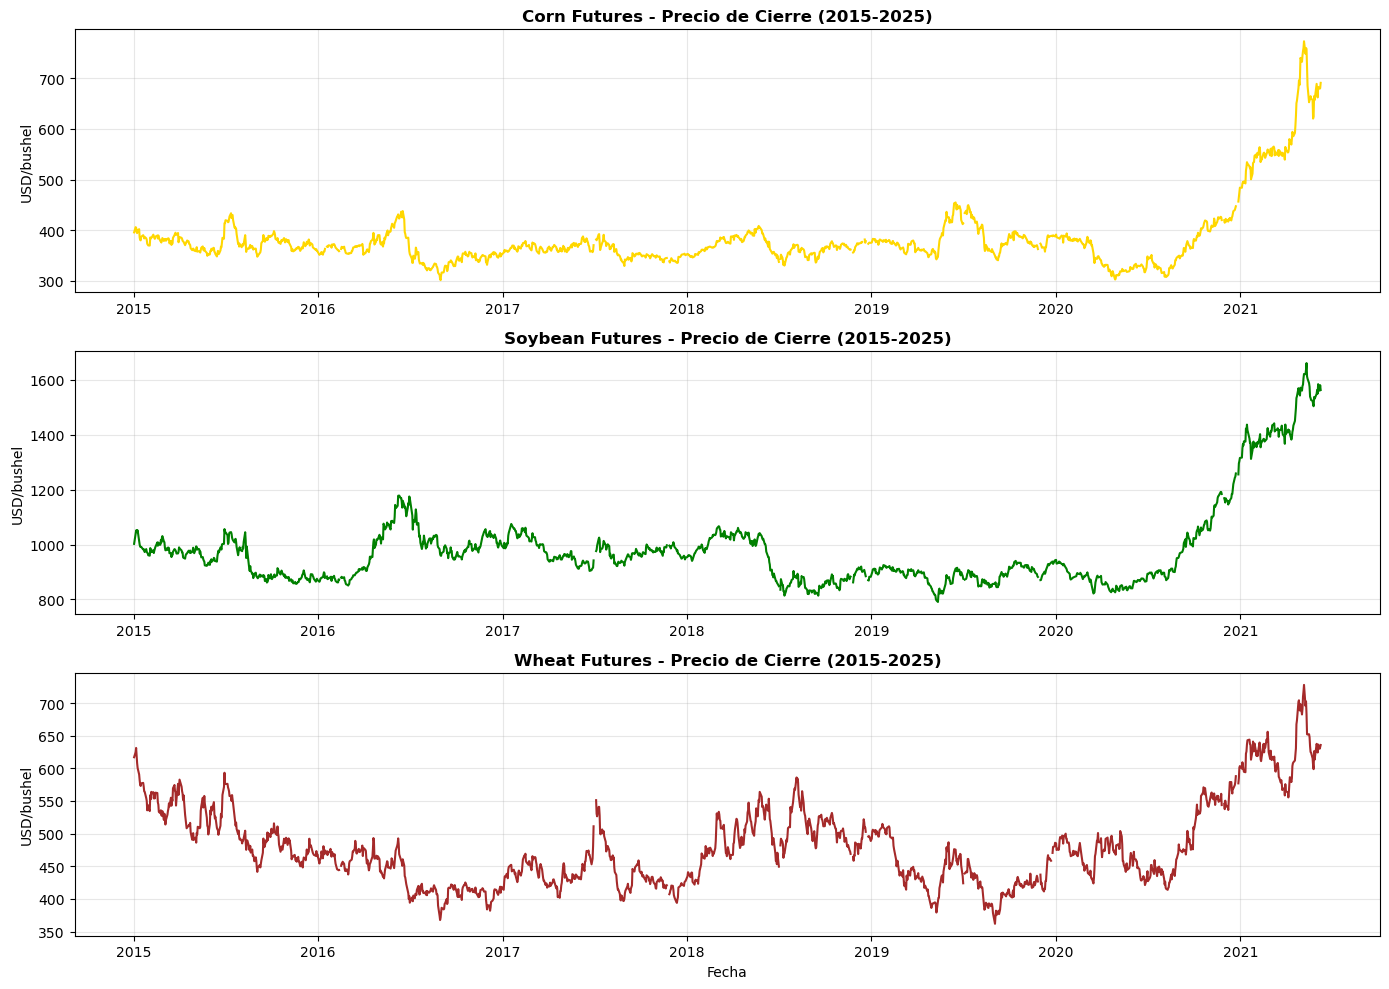

📊 Precios históricos - Últimos 10 años


In [52]:
import matplotlib.pyplot as plt

if chris_data and len(chris_data) > 0:
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    commodities = [
        ('Corn', 'Corn Futures', 'gold'),
        ('Soybeans', 'Soybean Futures', 'green'),
        ('Wheat', 'Wheat Futures', 'brown')
    ]
    
    for idx, (key, title, color) in enumerate(commodities):
        ax = axes[idx]
        
        if key in chris_data:
            df = chris_data[key].copy()
            df = df[df['Date'] >= '2015-01-01']
            
            price_col = 'Close' if 'Close' in df.columns else 'Adj Close'
            
            ax.plot(df['Date'], df[price_col], color=color, linewidth=1.5)
            ax.set_title(f'{title} - Precio de Cierre (2015-2025)', 
                        fontsize=12, fontweight='bold')
            ax.set_ylabel('USD/bushel')
            ax.grid(True, alpha=0.3)
            
            if idx == 2:
                ax.set_xlabel('Fecha')
        else:
            ax.text(0.5, 0.5, f'Datos no disponibles: {key}', 
                   ha='center', va='center', fontsize=12, color='red')
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Precios históricos - Últimos 10 años")

else:
    print("⚠️  Imposible generar gráficos sin datos")
    print("Descargar datasets según instrucciones en celda 1")

---

## 2. Descarga de Datos Actualizados (Yahoo Finance vía yfinance)

**Problema:** Los datos de Kaggle solo llegan hasta junio 2021.

**Solución:** Descargar datos recientes desde Yahoo Finance (2021-2025) para empalmar con históricos de Kaggle.

**Requisito:**
```bash
pip install yfinance
```


In [53]:
# Importar yfinance
try:
    import yfinance as yf
    print("✓ yfinance disponible")
    print(f"  Versión: {yf.__version__ if hasattr(yf, '__version__') else 'desconocida'}")
except ImportError:
    print("⚠️  yfinance NO INSTALADO")
    print("\n📦 Para instalar:")
    print("   pip install yfinance")
    print("\n⚠️  Sin yfinance, solo se usarán datos de Kaggle (hasta 2021)")
    yf = None


✓ yfinance disponible
  Versión: 0.2.65


### Test: Verificar disponibilidad histórica en Yahoo Finance

Probamos cuánto retrocede Yahoo Finance para algunos commodities clave.

In [54]:
if yf is not None:
    print("🔍 Verificando cobertura histórica de Yahoo Finance...\n")
    
    # Probar algunos commodities clave
    test_tickers = {
        'Gold': 'GC=F',
        'Crude Oil': 'CL=F',
        'Corn': 'ZC=F',
        'Soybeans': 'ZS=F',
        'Silver': 'SI=F',
        'Natural Gas': 'NG=F'
    }
    
    print(f"{'Commodity':<15} {'Ticker':<8} {'Desde':<12} {'Hasta':<12} {'Años':<6} {'Obs.':<8}")
    print("=" * 70)
    
    for name, ticker in test_tickers.items():
        try:
            # Descargar desde 1990
            df = yf.download(ticker, start='1990-01-01', progress=False)
            
            if not df.empty:
                df = df.reset_index()
                fecha_min = df['Date'].min().strftime('%Y-%m-%d')
                fecha_max = df['Date'].max().strftime('%Y-%m-%d')
                years = (df['Date'].max() - df['Date'].min()).days / 365.25
                obs = len(df)
                
                print(f"{name:<15} {ticker:<8} {fecha_min:<12} {fecha_max:<12} {years:<6.1f} {obs:<8,}")
            else:
                print(f"{name:<15} {ticker:<8} {'SIN DATOS':<12}")
        except Exception as e:
            print(f"{name:<15} {ticker:<8} ERROR: {str(e)[:30]}")
    
    print("\n💡 Conclusión:")
    print("   - Si los datos van hasta ~1993-1995, podemos usar Yahoo Finance")
    print("   - Si van hasta 1990, ¡MEJOR AÚN! Reemplazamos Kaggle completamente")
    print("   - Si solo van hasta 2000+, mantenemos arquitectura Kaggle+Yahoo")
else:
    print("⚠️  Instalar yfinance primero: pip install yfinance")

🔍 Verificando cobertura histórica de Yahoo Finance...

Commodity       Ticker   Desde        Hasta        Años   Obs.    
Gold            GC=F     2000-08-30   2025-10-27   25.2   6,313   
Crude Oil       CL=F     2000-08-23   2025-10-27   25.2   6,322   
Corn            ZC=F     2000-07-17   2025-10-27   25.3   6,325   
Soybeans        ZS=F     2000-09-15   2025-10-27   25.1   6,317   
Silver          SI=F     2000-08-30   2025-10-27   25.2   6,315   
Natural Gas     NG=F     2000-08-30   2025-10-27   25.2   6,319   

💡 Conclusión:
   - Si los datos van hasta ~1993-1995, podemos usar Yahoo Finance
   - Si van hasta 1990, ¡MEJOR AÚN! Reemplazamos Kaggle completamente
   - Si solo van hasta 2000+, mantenemos arquitectura Kaggle+Yahoo


### 2.1. Descargar datos recientes (2021-2025)

In [ ]:
from datetime import timedelta

# Mapeo COMPLETO de tickers Yahoo Finance
ticker_mapping = {
    # Granos y oleaginosas
    'Corn': 'ZC=F',
    'Soybeans': 'ZS=F',
    'Wheat': 'ZW=F',
    'Soybean_Oil': 'ZL=F',
    'Soybean_Meal': 'ZM=F',
    'Oat': 'ZO=F',
    
    # Energía
    'Crude_Oil': 'CL=F',
    'Brent_Crude_Oil': 'BZ=F',
    'Natural_Gas': 'NG=F',
    'Heating_Oil': 'HO=F',
    'RBOB_Gasoline': 'RB=F',
    
    # Metales preciosos
    'Gold': 'GC=F',
    'Silver': 'SI=F',
    'Platinum': 'PL=F',
    'Palladium': 'PA=F',
    
    # Metales industriales
    'Copper': 'HG=F',
    
    # Softs
    'Coffee': 'KC=F',
    'Sugar': 'SB=F',
    'Cotton': 'CT=F',
    'Cocoa': 'CC=F',
    
    # Ganado
    'Live_Cattle': 'LE=F',
    'Feeder_Cattle': 'GF=F',
    'Lean_Hogs': 'HE=F',
    
    # Madera
    'Lumber': 'LBS=F'
}

yahoo_data = {}

if yf is not None:
    print("=" * 80)
    print("DESCARGANDO DATOS RECIENTES DESDE YAHOO FINANCE (2021-2025)")
    print("=" * 80 + "\n")
    
    # Determinar fecha de inicio (30 días antes de última fecha Kaggle para overlap)
    start_date = '2021-05-01'  # 1 mes antes de fin de Kaggle (2021-06-09)
    
    print(f"📅 Período: {start_date} → {datetime.now().strftime('%Y-%m-%d')}")
    print(f"📊 Commodities a descargar: {len(ticker_mapping)}\n")
    
    for commodity_name, ticker in ticker_mapping.items():
        try:
            # Descargar
            df = yf.download(ticker, start=start_date, progress=False)
            
            if df.empty:
                print(f"  ✗ {commodity_name:20} ({ticker:8}): Sin datos")
                continue
            
            # Resetear índice
            df = df.reset_index()
            
            # Aplanar MultiIndex si existe
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            
            # Estandarizar columnas
            df.columns = df.columns.str.lower()
            if 'adj close' in df.columns:
                df = df.rename(columns={'adj close': 'adj_close'})
            
            df['date'] = pd.to_datetime(df['date'])
            df['commodity'] = commodity_name
            
            # Guardar en diccionario
            yahoo_data[commodity_name] = df
            
            # Guardar CSV individual
            output_file = RAW_DIR / 'kaggle' / 'mattiuzc_futures' / f'{commodity_name.lower()}_yahoo.csv'
            df.to_csv(output_file, index=False)
            
            print(f"  ✓ {commodity_name:20} ({ticker:8}): {len(df):>6,} días | "
                  f"{df['date'].min().strftime('%Y-%m-%d')} → {df['date'].max().strftime('%Y-%m-%d')}")
            
        except Exception as e:
            print(f"  ✗ {commodity_name:20} ({ticker:8}): ERROR - {str(e)[:50]}")
    
    print("\n" + "=" * 80)
    print(f"✓ DESCARGADOS: {len(yahoo_data)}/{len(ticker_mapping)} commodities")
    print("=" * 80)
else:
    print("⚠️  yfinance no disponible - instalar para descargar datos recientes")
    print("   pip install yfinance")

DESCARGANDO SERIE HISTÓRICA COMPLETA DESDE YAHOO FINANCE (1990-2025)

📅 Período solicitado: 1990-01-01 → 2025-10-27
📊 Commodities a descargar: 24

  ✓ Corn                 (ZC=F    ):  6,325 días | 2000-07-17 → 2025-10-27 (25.3 años)
  ✓ Corn                 (ZC=F    ):  6,325 días | 2000-07-17 → 2025-10-27 (25.3 años)
  ✓ Soybeans             (ZS=F    ):  6,317 días | 2000-09-15 → 2025-10-27 (25.1 años)
  ✓ Soybeans             (ZS=F    ):  6,317 días | 2000-09-15 → 2025-10-27 (25.1 años)
  ✓ Wheat                (ZW=F    ):  6,337 días | 2000-07-17 → 2025-10-27 (25.3 años)
  ✓ Wheat                (ZW=F    ):  6,337 días | 2000-07-17 → 2025-10-27 (25.3 años)
  ✓ Soybean_Oil          (ZL=F    ):  6,366 días | 2000-03-15 → 2025-10-27 (25.6 años)
  ✓ Soybean_Oil          (ZL=F    ):  6,366 días | 2000-03-15 → 2025-10-27 (25.6 años)
  ✓ Soybean_Meal         (ZM=F    ):  6,328 días | 2000-05-15 → 2025-10-27 (25.5 años)
  ✓ Soybean_Meal         (ZM=F    ):  6,328 días | 2000-05-15 → 2025-1


1 Failed download:
['HG=F']: Timeout('Failed to perform, curl: (28) Operation timed out after 10004 milliseconds with 23404 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['HG=F']: Timeout('Failed to perform, curl: (28) Operation timed out after 10004 milliseconds with 23404 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


  ✗ Copper               (HG=F    ): Sin datos
  ✓ Coffee               (KC=F    ):  6,473 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Coffee               (KC=F    ):  6,473 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Sugar                (SB=F    ):  6,436 días | 2000-03-01 → 2025-10-27 (25.7 años)
  ✓ Sugar                (SB=F    ):  6,436 días | 2000-03-01 → 2025-10-27 (25.7 años)
  ✓ Cotton               (CT=F    ):  6,475 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Cotton               (CT=F    ):  6,475 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Cocoa                (CC=F    ):  6,475 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Cocoa                (CC=F    ):  6,475 días | 2000-01-03 → 2025-10-27 (25.8 años)
  ✓ Live_Cattle          (LE=F    ):  6,180 días | 2001-03-01 → 2025-10-27 (24.7 años)
  ✓ Live_Cattle          (LE=F    ):  6,180 días | 2001-03-01 → 2025-10-27 (24.7 años)
  ✓ Feeder_Cattle        (GF=F    ):  6,150 días | 2001-04-03 → 2025-10-27 (24.6 añ

---

## 3. Resumen Final


In [56]:
print("=" * 60)
print("RESUMEN - DATOS DESCARGADOS")
print("=" * 60)

print("\n1️⃣  KAGGLE - Commodity Futures (Históricos 2000-2021):")
if 'chris_data' in locals() and chris_data and len(chris_data) > 0:
    for commodity, df in chris_data.items():
        print(f"  ✓ {commodity}: {len(df):,} días ({df['Date'].min().date()} → {df['Date'].max().date()})")
else:
    print("  ✗ No cargado")
    print("     Descargar: https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history")

print("\n2️⃣  YAHOO FINANCE - Datos Recientes (2021-2025):")
if 'yahoo_data' in locals() and yahoo_data and len(yahoo_data) > 0:
    for commodity, df in list(yahoo_data.items())[:5]:
        print(f"  ✓ {commodity}: {len(df):,} días ({df['date'].min().date()} → {df['date'].max().date()})")
    if len(yahoo_data) > 5:
        print(f"  ... y {len(yahoo_data) - 5} commodities más")
else:
    print("  ⚠️  No descargado - ejecutar Sección 2 primero")
    print("     Requiere: pip install yfinance")

print("\n" + "=" * 60)
total_commodities = len(yahoo_data) if 'yahoo_data' in locals() else 0
status = f"✅ {total_commodities} COMMODITIES CON DATOS COMPLETOS" if total_commodities > 0 else "⚠️  ACCIÓN REQUERIDA"
print(status)
print("\n📂 Ubicación: data/raw/kaggle/mattiuzc_futures/")
print("🎯 Siguiente paso: 02_process_data.ipynb")
print("=" * 60)


RESUMEN - DATOS DESCARGADOS

1️⃣  KAGGLE - Commodity Futures (Históricos 2000-2021):
  ✓ Brent_Crude_Oil: 3,492 días (2007-07-30 → 2021-06-09)
  ✓ brent_crude_oil_yahoo: 1,131 días (2021-05-03 → 2025-10-27)
  ✓ Cocoa: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ cocoa_yahoo: 1,130 días (2021-05-03 → 2025-10-27)
  ✓ Coffee: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ coffee_yahoo: 1,131 días (2021-05-03 → 2025-10-27)
  ✓ Copper: 5,291 días (2000-08-30 → 2021-06-09)
  ✓ copper_yahoo: 1,131 días (2021-05-03 → 2025-10-27)
  ✓ Corn: 5,323 días (2000-07-17 → 2021-06-09)
  ✓ corn_yahoo: 1,129 días (2021-05-03 → 2025-10-27)
  ✓ Cotton: 5,463 días (2000-01-03 → 2021-06-09)
  ✓ cotton_yahoo: 1,131 días (2021-05-03 → 2025-10-27)
  ✓ Crude_Oil: 5,296 días (2000-08-23 → 2021-06-09)
  ✓ crude_oil_yahoo: 1,130 días (2021-05-03 → 2025-10-27)
  ✓ Feeder_Cattle: 4,898 días (2002-03-04 → 2021-06-09)
  ✓ feeder_cattle_yahoo: 1,129 días (2021-05-03 → 2025-10-27)
  ✓ Gold: 5,291 días (2000-08-30 → 2021-06-09)
  ✓ 

---

## Siguientes Pasos

### Procesamiento de datos (Notebook 02)

1. **Carga y empalme de fuentes**
   - Cargar archivos Kaggle (2000-2021)
   - Cargar archivos Yahoo Finance (2021-2025)
   - Empalmar series con overlap de 30 días para validación

2. **Limpieza y normalización**
   - Estandarizar nombres de columnas
   - Tratamiento de valores faltantes
   - Detección de outliers

3. **Feature engineering**
   - Retornos logarítmicos (1d, 5d, 20d, 60d)
   - Medias móviles (SMA 20, 50, 200)
   - Volatilidad histórica (ventanas 30/60 días)
   - Señales técnicas (price vs SMA)

4. **Visualizaciones**
   - Series temporales de precios
   - Volatilidad histórica por año
   - Matriz de correlaciones
   - Distribución de retornos

5. **Exportación**
   - Dataset final: `data/processed/commodities_base_daily.csv`
   - Metadata: `data/processed/metadata.json`

---

### Referencias técnicas

**Fuentes de datos:**
- Kaggle mattiuzc: https://www.kaggle.com/datasets/mattiuzc/commodity-futures-price-history
- Yahoo Finance: Vía librería yfinance (https://pypi.org/project/yfinance/)

**Documentación del proyecto:**
- `meta/sources.md` - Detalle de fuentes y tickers
- `meta/data_dictionary.md` - Diccionario de variables

---

**Actualizado:** 27/10/2025
